# Model-7: Caltech 256 Dataset, Resize to 256x256, Sigmoid in Final Layers, Batch Normalization, Mixed Precision, Residual Blocks

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

import torchvision
from torchvision import datasets

In [2]:
try:
    from torchinfo import summary
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "torchinfo"])
    from torchinfo import summary

In [3]:
try:
    import torchmetrics
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "torchmetrics"])
    import torchmetrics

In [4]:
import os
repo_url = "https://raw.githubusercontent.com/vardanskamra/Deep-Multimedia-Steganography/main/utils"
files = [
    "__init__.py",
    "test.py",
    "train.py",
    "metrics.py",
    "transforms.py",
    "visualizations.py",
    "inference.py",
    "attacks.py"
]
os.makedirs("utils", exist_ok=True)

for file in files:
    file_url = f"{repo_url}/{file}"
    os.system(f"curl -s -f {file_url} -o utils/{file}")

print("Downloaded all utils files successfully!")

Downloaded all utils files successfully!


In [5]:
import sys
sys.path.append("./utils") 

In [6]:
import utils

from utils.transforms import caltech256_train_test_transform_256x256
from utils.metrics import loss_function
from utils.train import train_with_attacks
from utils.test import test_with_attacks
from utils.attacks import random_attack, apply_attacks

from utils.visualizations import plot_metrics
from utils.visualizations import visualize_images

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
dataset = datasets.Caltech256(root='./data', download=True, transform=caltech256_train_test_transform_256x256)

# Using x% of the dataset
subset_size = int(0.5 * len(dataset))  
train_size = int(0.8 * subset_size)  
test_size = subset_size - train_size  

subset_dataset, _ = torch.utils.data.random_split(dataset, [subset_size, len(dataset) - subset_size])

train_dataset, test_dataset = torch.utils.data.random_split(subset_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=os.cpu_count(), drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=True)


Files already downloaded and verified


In [9]:
def get_min_max(loader):
    min_vals = []
    max_vals = []
    
    for inputs, _ in loader:
        # Flatten the inputs tensor to make sure we check all values
        min_vals.append(inputs.min().item())
        max_vals.append(inputs.max().item())
    
    # Calculate the overall min and max across the dataset
    overall_min = min(min_vals)
    overall_max = max(max_vals)
    
    return overall_min, overall_max

# Get the min and max values for the train dataset
train_min, train_max = get_min_max(train_loader)
print(f"Train dataset - Min: {train_min}, Max: {train_max}")

# Get the min and max values for the test dataset
test_min, test_max = get_min_max(test_loader)
print(f"Test dataset - Min: {test_min}, Max: {test_max}")

Train dataset - Min: 0.0, Max: 1.0
Test dataset - Min: 0.0, Max: 1.0


In [10]:
print(f"Train Dataset Length: {len(train_dataset)}")
print(f"Test Dataset Length: {len(test_dataset)}")
print(f"Train DataLoader Length: {len(train_loader)}")
print(f"Test DataLoader Length: {len(test_loader)}")

sample, label = next(iter(train_loader))
print(f"Sample Shape: {sample.shape}")
print(f"Label Shape: {label.shape}")

Train Dataset Length: 12242
Test Dataset Length: 3061
Train DataLoader Length: 382
Test DataLoader Length: 95
Sample Shape: torch.Size([32, 3, 256, 256])
Label Shape: torch.Size([32])


In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(channels)
        self.silu  = nn.SiLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(channels)
        
    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.silu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += residual
        out = self.silu(out)
        return out

In [12]:
class PrepNetwork(nn.Module):
    """
    A full-scale autoencoder to process (prepare) the secret image.
    Downsamples 256x256 images to a low-dimensional representation and upsamples back.
    """
    def __init__(self):
        super(PrepNetwork, self).__init__()
        # Encoder: 256 -> 128 -> 64 -> 32
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),  # 256 -> 128
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # 128 -> 64
            nn.BatchNorm2d(128),
            nn.SiLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),  # 64 -> 32
            nn.BatchNorm2d(256),
            nn.SiLU()
        )
        # Decoder: 32 -> 64 -> 128 -> 256
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),  # 32 -> 64
            nn.BatchNorm2d(128),
            nn.SiLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # 64 -> 128
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # 128 -> 256
            nn.Sigmoid()  # ensure output in [0, 1]
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [13]:
class HidingNetwork(nn.Module):
    """
    Hides the processed secret in the cover image.
    Uses a deeper network with residual blocks to capture fine details.
    """
    def __init__(self):
        super(HidingNetwork, self).__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(6, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.resblock1 = ResidualBlock(64)
        self.resblock2 = ResidualBlock(64)
        self.resblock3 = ResidualBlock(64)
        self.resblock4 = ResidualBlock(64)
        self.resblock5 = ResidualBlock(64)
        self.resblock6 = ResidualBlock(64)
        self.final = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()  # output stego image in [0, 1]
        )
    
    def forward(self, cover, secret_prepared):
        x = torch.cat([cover, secret_prepared], dim=1)
        x = self.initial(x)
        x = self.resblock1(x)
        x = self.resblock2(x)
        x = self.resblock3(x)
        x = self.resblock4(x)
        x = self.resblock5(x)
        x = self.resblock6(x)
        x = self.final(x)
        return x

In [14]:
class RevealNetwork(nn.Module):
    """
    Reveals the secret from the stego image.
    Uses a similar residual-based architecture to extract hidden signals.
    """
    def __init__(self):
        super(RevealNetwork, self).__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.resblock1 = ResidualBlock(64)
        self.resblock2 = ResidualBlock(64)
        self.resblock3 = ResidualBlock(64)
        self.resblock4 = ResidualBlock(64)
        self.resblock5 = ResidualBlock(64)
        self.final = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()  # output revealed secret in [0, 1]
        )
    
    def forward(self, stego):
        x = self.initial(stego)
        x = self.resblock1(x)
        x = self.resblock2(x)
        x = self.resblock3(x)
        x = self.resblock4(x)
        x = self.resblock5(x)
        x = self.final(x)
        return x


In [15]:
print(f"Device: {device}")
prep_net = nn.DataParallel(PrepNetwork()).to(device)
hide_net = nn.DataParallel(HidingNetwork()).to(device)
reveal_net = nn.DataParallel(RevealNetwork()).to(device)

Device: cuda


In [16]:
print("PrepNetwork Summary:")
print(summary(prep_net, input_size=(32, 3, 256, 256)))

cover = torch.randn(32, 3, 256, 256).to(device)
secret_prepared = torch.randn(32, 3, 256, 256).to(device)

print("\nHidingNetwork Summary:")
print(summary(hide_net, input_data=[cover, secret_prepared])) # 6 channels (cover + secret_prepared)

print("\nRevealNetwork Summary:")
print(summary(reveal_net, input_size=(32, 3, 256, 256)))

PrepNetwork Summary:
Layer (type:depth-idx)                   Output Shape              Param #
DataParallel                             [32, 3, 256, 256]         --
├─PrepNetwork: 1-1                       [16, 3, 256, 256]         742,659
├─PrepNetwork: 1-4                       --                        (recursive)
│    └─Sequential: 2-1                   [16, 256, 32, 32]         371,712
│    └─Sequential: 2-4                   --                        (recursive)
│    │    └─Conv2d: 3-1                  [16, 64, 128, 128]        1,792
├─PrepNetwork: 1-3                       [16, 3, 256, 256]         --
├─PrepNetwork: 1-4                       --                        (recursive)
│    └─Sequential: 2-3                   [16, 256, 32, 32]         --
│    └─Sequential: 2-4                   --                        (recursive)
│    │    └─Conv2d: 3-2                  [16, 64, 128, 128]        --
│    │    └─BatchNorm2d: 3-3             [16, 64, 128, 128]        --
│    │    └─Bat

In [17]:
optimizer = torch.optim.Adam(list(prep_net.parameters()) +
                       list(hide_net.parameters()) +
                       list(reveal_net.parameters()), lr=0.001)

In [18]:
checkpoint = torch.load('/kaggle/working/model_checkpoint.pth', map_location=device)

<ipython-input-18-bd1d4e427947>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('/kaggle/input/checkpoint_7/pytorch/default/1/model_checkpoint.pth',

In [20]:
train_metrics = train_with_attacks(dataloader=train_loader,
                prep_net=prep_net,
                hide_net=hide_net,
                reveal_net=reveal_net,
                optimizer=optimizer,
                loss_fn=loss_function,
                beta=0.75,
                epochs=20,
                checkpoint=checkpoint,
                device=device)

/usr/local/lib/python3.10/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `PeakSignalNoiseRatio` from `torchmetrics` was deprecated and will be removed in 2.0. Import `PeakSignalNoiseRatio` from `torchmetrics.image` instead.
  _future_warning(
/usr/local/lib/python3.10/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


Epoch [11/20], Loss: 0.0117, PSNR: 25.4028, SSIM: 0.8640, NC: 0.9428, Pixel Loss (Cover-Stego): 0.0388, Pixel Loss (Secret-Revealed): 0.0769
Epoch [12/20], Loss: 0.0100, PSNR: 25.6729, SSIM: 0.8674, NC: 0.9520, Pixel Loss (Cover-Stego): 0.0375, Pixel Loss (Secret-Revealed): 0.0694
Epoch [13/20], Loss: 0.0095, PSNR: 25.6969, SSIM: 0.8734, NC: 0.9567, Pixel Loss (Cover-Stego): 0.0374, Pixel Loss (Secret-Revealed): 0.0670
Epoch [14/20], Loss: 0.0095, PSNR: 25.6272, SSIM: 0.8720, NC: 0.9557, Pixel Loss (Cover-Stego): 0.0377, Pixel Loss (Secret-Revealed): 0.0669
Epoch [15/20], Loss: 0.0088, PSNR: 25.8642, SSIM: 0.8768, NC: 0.9605, Pixel Loss (Cover-Stego): 0.0365, Pixel Loss (Secret-Revealed): 0.0638
Epoch [16/20], Loss: 0.0091, PSNR: 25.8531, SSIM: 0.8764, NC: 0.9581, Pixel Loss (Cover-Stego): 0.0368, Pixel Loss (Secret-Revealed): 0.0652
Epoch [17/20], Loss: 0.0109, PSNR: 24.4795, SSIM: 0.8495, NC: 0.9533, Pixel Loss (Cover-Stego): 0.0440, Pixel Loss (Secret-Revealed): 0.0698
Epoch [18/20]

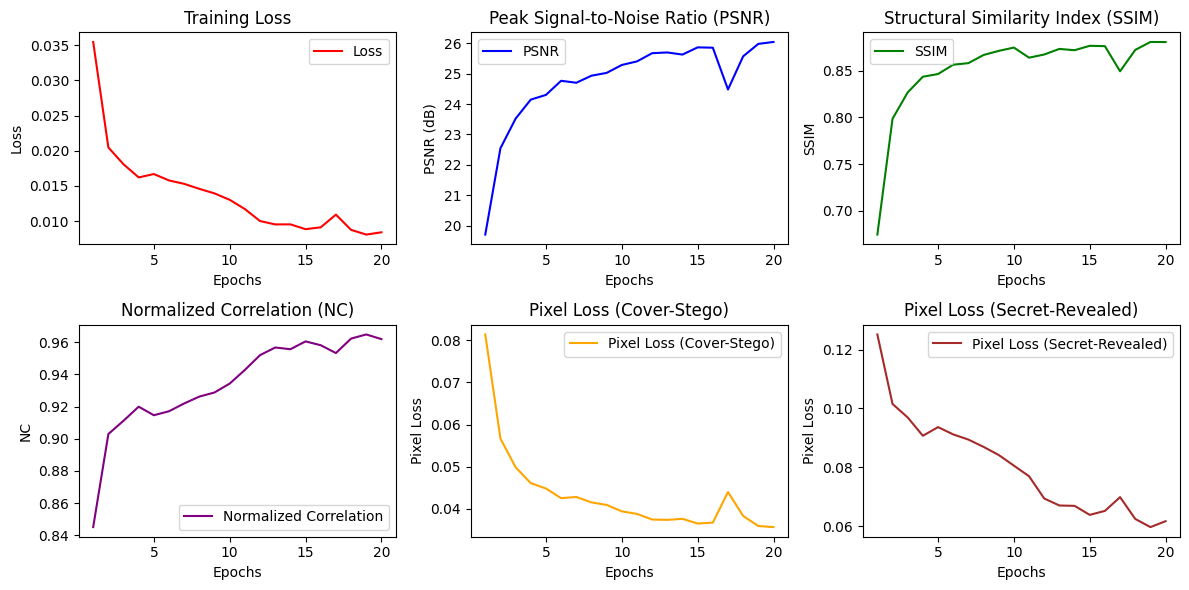


Final Evaluation Metrics:
Final Loss: 0.0084
Final PSNR: 26.0417 dB
Final SSIM: 0.8808
Final Normalized Correlation (NC): 0.9619
Final Pixel Loss (Cover-Stego): 0.0357
Final Pixel Loss (Secret-Revealed): 0.0617



In [21]:
plot_metrics(train_metrics)

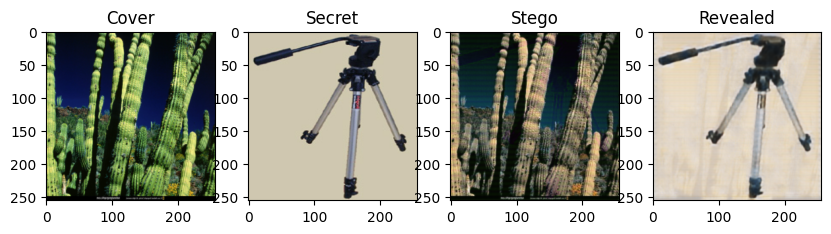

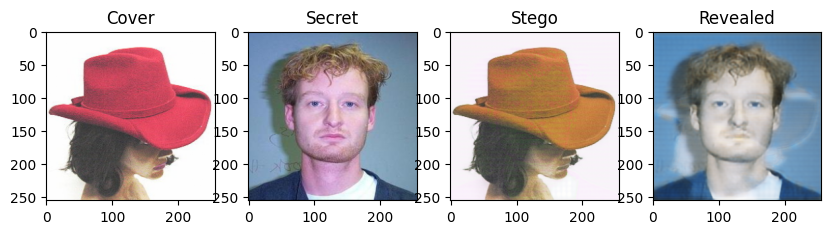

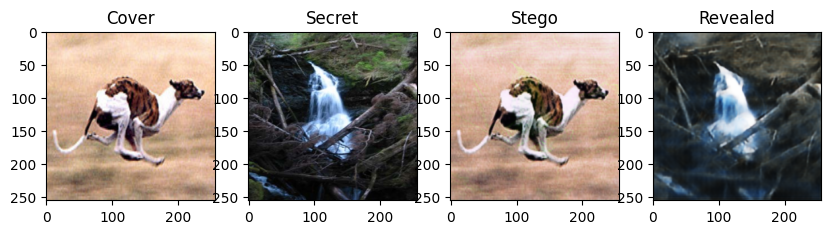

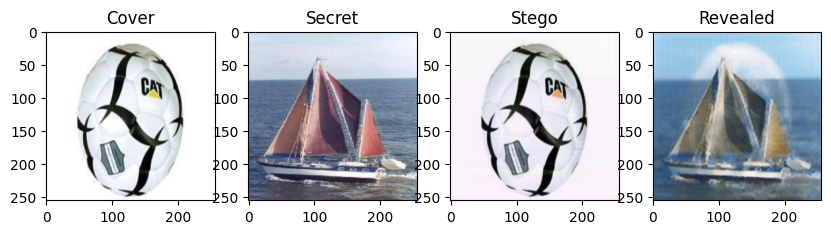


Test Results (Attacks: None): Loss: 0.0086, PSNR: 26.9817, SSIM: 0.9132, NC: 0.9633, Pixel Loss (Cover-Stego): 0.0310, Pixel Loss (Secret-Revealed): 0.0702



In [22]:
test_metrics = test_with_attacks(prep_net=prep_net,
               hide_net=hide_net,
               reveal_net=reveal_net,
               dataloader=test_loader,
               loss_fn = loss_function,
               beta = 0.75,
               visualize = 10,
               attacks=None,                  
               device=device)

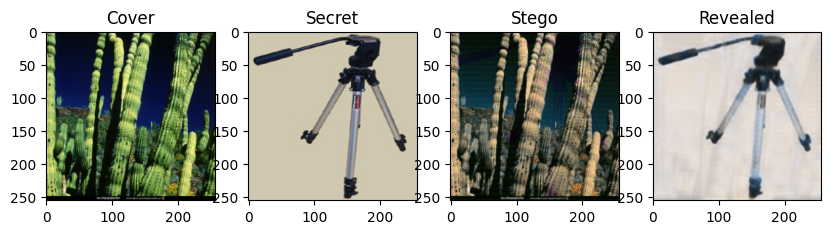

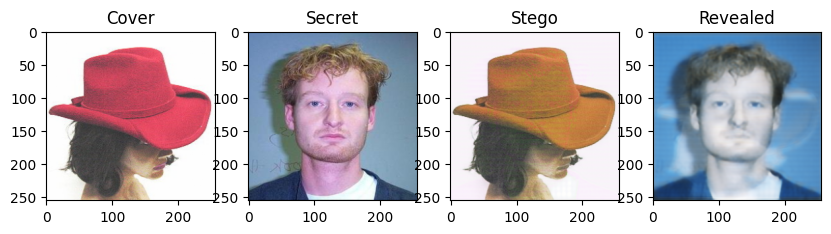

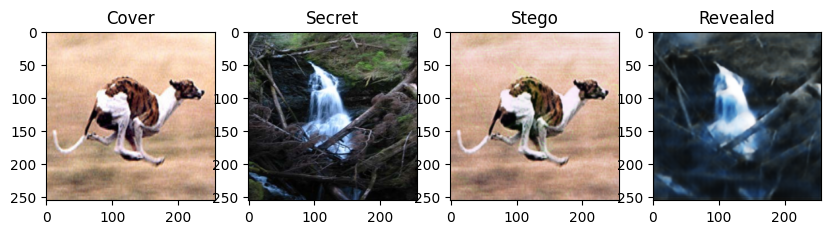

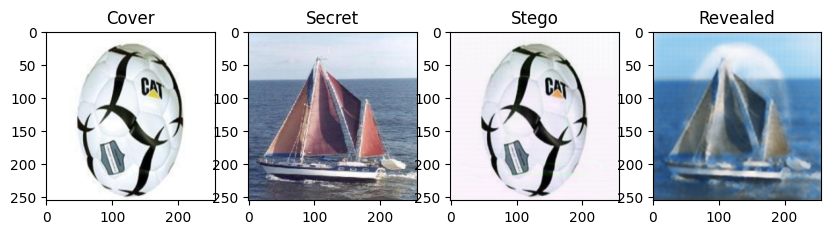


Test Results (Attacks: ['gaussian_1']): Loss: 0.0113, PSNR: 26.9817, SSIM: 0.9132, NC: 0.9418, Pixel Loss (Cover-Stego): 0.0310, Pixel Loss (Secret-Revealed): 0.0829



In [23]:
test_metrics = test_with_attacks(prep_net=prep_net,
               hide_net=hide_net,
               reveal_net=reveal_net,
               dataloader=test_loader,
               loss_fn = loss_function,
               beta = 0.75,
               visualize = 10,
               attacks=['gaussian_1'],                  
               device=device)

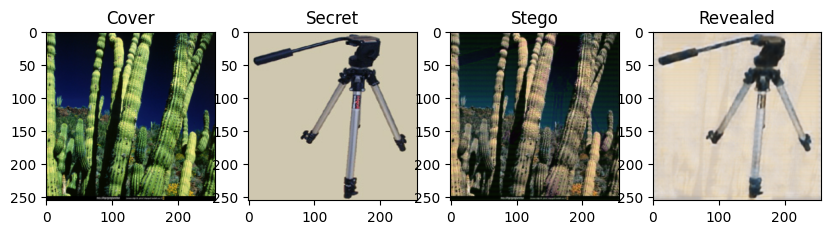

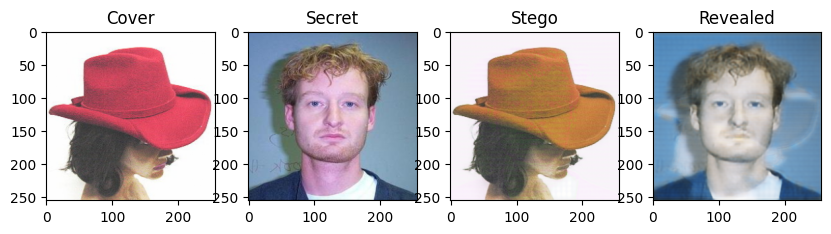

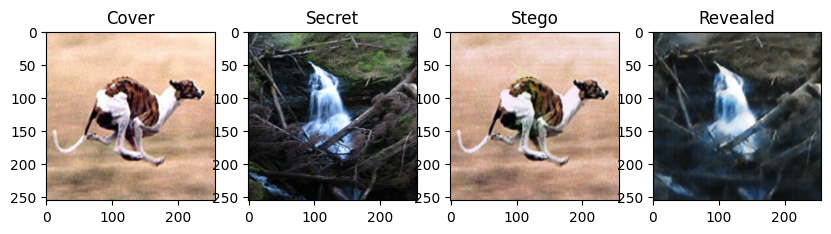

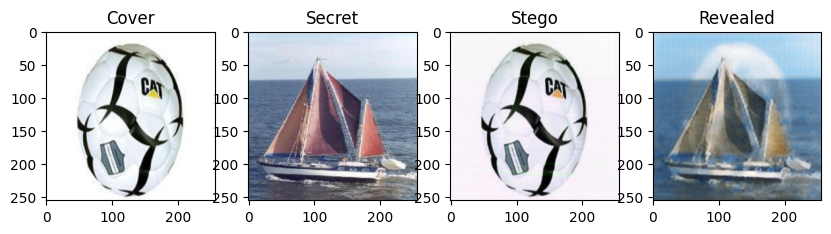


Test Results (Attacks: ['gaussian_0.1']): Loss: 0.0086, PSNR: 26.9817, SSIM: 0.9132, NC: 0.9633, Pixel Loss (Cover-Stego): 0.0310, Pixel Loss (Secret-Revealed): 0.0702



In [24]:
test_metrics = test_with_attacks(prep_net=prep_net,
               hide_net=hide_net,
               reveal_net=reveal_net,
               dataloader=test_loader,
               loss_fn = loss_function,
               beta = 0.75,
               visualize = 10,
               attacks=['gaussian_0.1'],                  
               device=device)

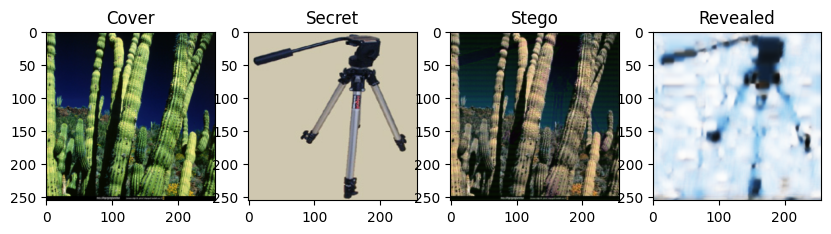

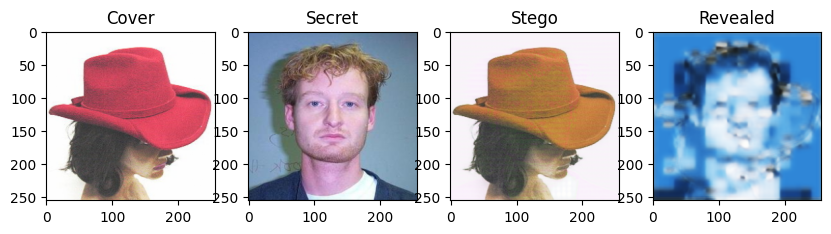

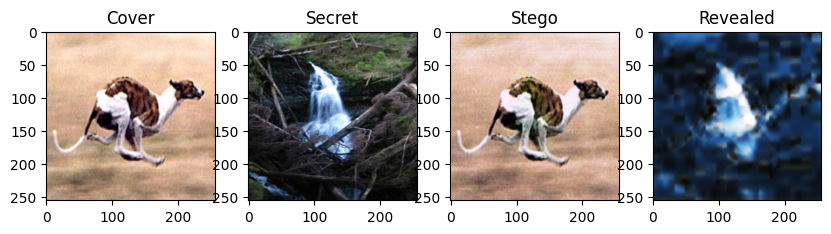

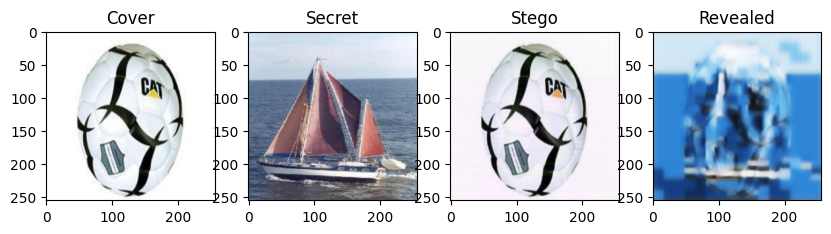


Test Results (Attacks: ['jpeg']): Loss: 0.0336, PSNR: 26.9817, SSIM: 0.9132, NC: 0.8046, Pixel Loss (Cover-Stego): 0.0310, Pixel Loss (Secret-Revealed): 0.1479



In [25]:
test_metrics = test_with_attacks(prep_net=prep_net,
               hide_net=hide_net,
               reveal_net=reveal_net,
               dataloader=test_loader,
               loss_fn = loss_function,
               beta = 0.75,
               visualize = 10,
               attacks=['jpeg'],                  
               device=device)

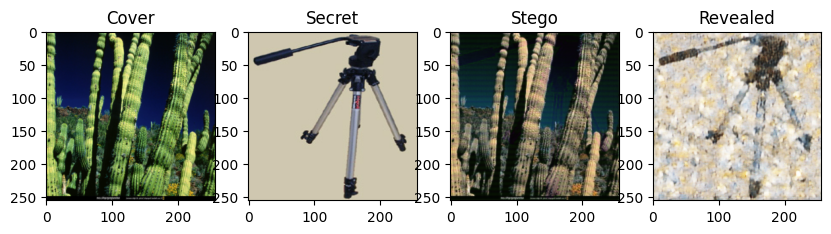

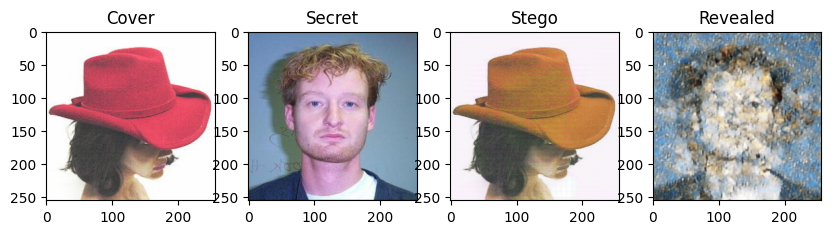

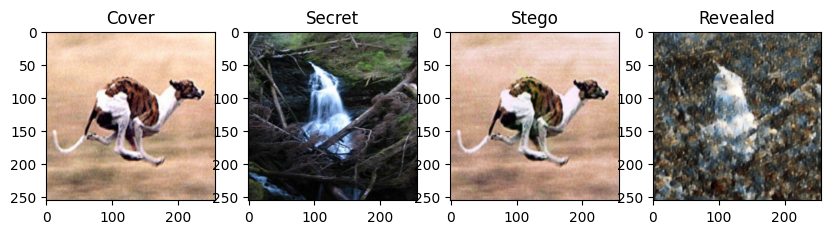

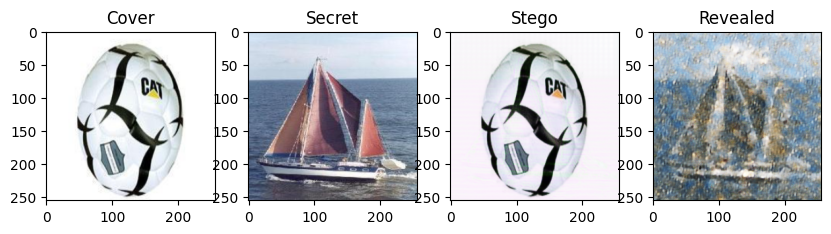


Test Results (Attacks: ['salt_and_pepper']): Loss: 0.0194, PSNR: 26.9817, SSIM: 0.9132, NC: 0.8943, Pixel Loss (Cover-Stego): 0.0310, Pixel Loss (Secret-Revealed): 0.1155



In [26]:
test_metrics = test_with_attacks(prep_net=prep_net,
               hide_net=hide_net,
               reveal_net=reveal_net,
               dataloader=test_loader,
               loss_fn = loss_function,
               beta = 0.75,
               visualize = 10,
               attacks=['salt_and_pepper'],                  
               device=device)

In [27]:
torch.save(prep_net.state_dict(), "/kaggle/working/prep_net.pth")
torch.save(hide_net.state_dict(), "/kaggle/working/hide_net.pth")
torch.save(reveal_net.state_dict(), "/kaggle/working/reveal_net.pth")